# **Project 2a − Alloy Cluster Expansions**
## Advanced Simulation and Machine Learning | TIF345
## Chalmers University of Technology | Fall 2025
---
### Linus Brink | [brinkl@chalmers.se](mailto:brinkl@chalmers.se) 
### Oscar Stommendal | [oscarsto@chalmers.se](mailto:oscarsto@chalmers.se)
---

## **Setup**

In [135]:
### Imports and plotting settings ###

import ase
import icet

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import scipy
import emcee

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import Ridge
from sklearn.linear_model import ARDRegression
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

plt.rc('text', usetex = True)
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
font_size = 14
plt.rcParams['font.size'] = font_size
plt.rcParams['xtick.labelsize'] = font_size
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 5
plt.rcParams['ytick.major.size'] = 5
plt.rcParams['xtick.major.width'] = 1
plt.rcParams['ytick.major.width'] = 1
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'

def running_mean(x, factor):
    """
    Return the running mean of N element in a list.

    Args:
        x (ndarray): The list of elements,
        factor (float): The factor to multiply the length of the list by.
    
    Returns:
        ndarray: The running mean.
    """
    it, walker = x.shape
    N = int(factor * it)
    average = np.zeros((it - N+1,walker))
    #print(average.shape)
    for i in range(walker):
        cumsum = np.cumsum(np.insert(x[:,i], 0, 0))
        #print((cumsum[N:] - cumsum[:-N]).shape)
        average[:,i] = ((cumsum[N:] - cumsum[:-N]) / float(N))
    average = np.sum(average,axis=1) / walker

    return average

def trace_plotter(axs, sampler, iterations, sampler_idx=None, ndim=2, save=False):
    """
    Plot the traces of the MCMC chain.

    Args:
        axs (ndarray): The axes to plot on,
        sampler (emcee.EnsembleSampler): The sampler object,
        iterations (int): The number of iterations to plot,
        sampler_idx (str): The index of the sampler,
        ndim (int): The number of dimensions of the parameter space,
        save (bool): Whether to save the figure.
    """
    
    # If we have three parameters, plot the trace of sigma as well
    if ndim == 3:
        axs[0].plot([], [], 'k')
        axs[0].plot(running_mean(sampler.chain[:, :iterations, 0].T,factor=0.015),color='tab:red',alpha=1,linewidth = 2)#, label='Rolling average')
        axs[0].plot(sampler.chain[:, :iterations, 0].T, color='k', alpha=0.1)#, label='Traces $c_D$')
        axs[0].plot(running_mean(sampler.chain[:, :iterations, 0].T,factor=0.015),color='tab:red',alpha=1,linewidth = 2)#, label='Rolling average')
        axs[0].set_ylabel(r'$H_0$')
        axs[0].set_xticklabels([])
        axs[1].plot([], [], 'k')
        axs[1].plot(running_mean(sampler.chain[:, :iterations, 1].T,factor=0.015),color='tab:red',alpha=1,linewidth = 2)#, label='Rolling average')
        axs[1].plot(sampler.chain[:, :iterations, 1].T, color='k', alpha=0.1)#, label='Traces $c_E$')
        axs[1].plot(running_mean(sampler.chain[:, :iterations, 1].T,factor=0.015),color='tab:red',alpha=1,linewidth = 2)#, label='Rolling average')
        axs[1].set_ylabel(r'$q_0$')
        axs[1].set_xticklabels([])
        axs[2].plot([], [], 'k')
        axs[2].plot(running_mean(sampler.chain[:, :iterations, 2].T,factor=0.015),color='tab:red',alpha=1,linewidth = 2)
        axs[2].plot(sampler.chain[:, :iterations, 2].T, color='k', alpha=0.3)
        axs[2].plot(running_mean(sampler.chain[:, :iterations, 2].T,factor=0.015),color='tab:red',alpha=1,linewidth = 2)
        axs[2].set_ylabel(r'$\sigma_{\mathrm{sys}}^2$')
        axs[2].set_xlabel('Sampler Iteration')
        axs[2].legend(['Traces','Rolling averages'], loc = 'lower center', bbox_to_anchor=(0.47, -0.55), ncol=2)
    else:
        # If we have 3 or more parameters, plot all of them
        for i, ax in enumerate(axs):
            ax.plot([], [], 'k')
            ax.plot(running_mean(sampler.chain[:, :iterations, i].T,factor=0.015),color='tab:red',alpha=1,linewidth = 2)#, label='Rolling average')
            ax.plot(sampler.chain[:, :iterations, i].T, color='k', alpha=0.1)#, label='Traces $c_D$')
            ax.plot(running_mean(sampler.chain[:, :iterations, i].T,factor=0.015),color='tab:red',alpha=1,linewidth = 2)#, label='Rolling average')
            ax.set_ylabel(r'$J_{'+str(i)+'}$')
            # if i != len(axs) - 2:
            #     ax.set_xticklabels([])
            # else:
            #     ax.set_xlabel('Sampler Iteration')
        axs[-1].legend(['Traces','Rolling averages'], loc = 'lower center', bbox_to_anchor=(0.47, -0.55), ncol=2)

    if save:
        axs[0].figure.savefig('figs/post_samples'+sampler_idx+'.pdf', bbox_inches='tight')

def find_cu_concentration(comp):
    """
    Find the copper concentration in a given composition.

    Args:
        comp (str): The composition string, e.g. 'Au3Cu1'.
    
    Returns:
        float: The copper concentration.
    """

    formula = ase.formula.Formula(comp)
    count = formula.count()
    try:
        cu_concentration = count['Cu'] / sum(count.values())
    except KeyError:
        cu_concentration = 0.0

    return cu_concentration


## **Task 1: Prepare data**

In [184]:

db = ase.db.connect('data/AuCu-structures.db')

prim = db.get(formula='AuCu').toatoms()
cs = icet.ClusterSpace(prim, cutoffs=[8, 6, 5], chemical_symbols=['Au', 'Cu'])
print(cs)

# Initialize 3-dimensional array to hold composition, energy, and structure
data = {
    'composition': [],
    'energy': [],
    'structure': []
}
for row in db.select():
    atoms = row.toatoms()
    structure = atoms.cell
    energy = row.mixing_energy
    comp = atoms.get_chemical_formula()
    data['composition'].append(comp)
    data['energy'].append(energy)
    data['structure'].append(structure)
    

====================================== Cluster Space ======================================
 space group                            : Fm-3m (225)
 chemical species                       : ['Au', 'Cu'] (sublattice A)
 cutoffs                                : 8.0000 6.0000 5.0000
 total number of parameters             : 24
 number of parameters by order          : 0= 1  1= 1  2= 7  3= 12  4= 3
 fractional_position_tolerance          : 2e-06
 position_tolerance                     : 1e-05
 symprec                                : 1e-05
-------------------------------------------------------------------------------------------
index | order |  radius  | multiplicity | orbit_index | multicomponent_vector | sublattices
-------------------------------------------------------------------------------------------
   0  |   0   |   0.0000 |        1     |      -1     |           .           |      .     
   1  |   1   |   0.0000 |        1     |       0     |          [0]          |      A     


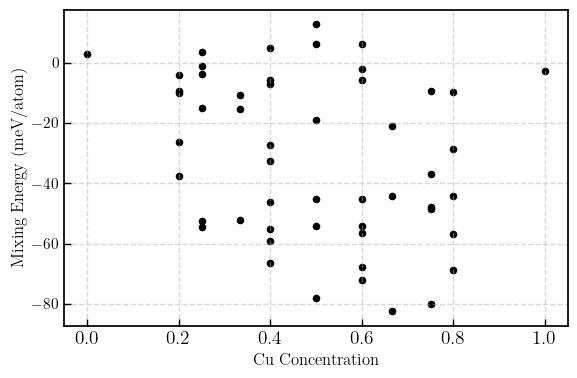

In [ ]:

comps = data['composition']
energies = np.array(data['energy'])

cu_concentrations = [find_cu_concentration(comp) for comp in comps]

plt.figure(figsize=(6, 4))
plt.scatter(cu_concentrations, energies * 1000, color='k', s=20, alpha=1)
plt.xlabel('Cu Concentration')
plt.ylabel('Mixing Energy (meV/atom)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
# plt.savefig('figs/au_cu_mixing_energy_vs_concentration.pdf', bbox_inches='tight')
plt.show()


## **Task 2: OLS and ridge regression**

In [186]:

sc = icet.StructureContainer(cs)
for row in db.select():
    sc.add_structure(row.toatoms(), properties=dict(mixing_energy=row.mixing_energy))
X, E = sc.get_fit_data(key='mixing_energy')

# Standardize features
scaler_X = StandardScaler()
X_std = scaler_X.fit_transform(X)
scaler_E = StandardScaler()
E_std = scaler_E.fit_transform(E.reshape(-1, 1)).flatten()

# OLS regression
ols = LinearRegression(fit_intercept=False)
ols.fit(X_std, E_std)
J_opt_OLS_std = ols.coef_

# Ridge regression, use K-fold cross validation to find optimal value for alpha
alphas = np.logspace(-5, 5, 100)
kf = KFold(n_splits=10, shuffle=True, random_state=42)
ridge_cv = RidgeCV(alphas=alphas, fit_intercept=False, cv=kf)
ridge_cv.fit(X_std, E_std)
alpha_opt = ridge_cv.alpha_
print(f'Optimal alpha for Ridge regression: {alpha_opt}')

ridge = Ridge(alpha=alpha_opt, fit_intercept=False)
ridge.fit(X_std, E_std)
J_opt_ridge_std = ridge.coef_


Optimal alpha for Ridge regression: 0.10974987654930568


In [ ]:

# Compute CV-RMSE for both models
scores_ols = cross_val_score(ols, X_std, E_std, cv=kf, scoring='neg_root_mean_squared_error')
rmse_ols = -np.mean(scores_ols)
rmse_ols_recovered = scaler_E.scale_[0] * rmse_ols
print(f'OLS CV-RMSE: {rmse_ols_recovered * 1000:.2f} meV/atom')

scores_ridge = cross_val_score(ridge, X_std, E_std, cv=kf, scoring='neg_root_mean_squared_error')
rmse_ridge = -np.mean(scores_ridge)
rmse_ridge_recovered = scaler_E.scale_[0] * rmse_ridge
print(f'Ridge CV-RMSE: {rmse_ridge_recovered * 1000:.2f} meV/atom')

J_opt_OLS_recovered = J_opt_OLS_std / scaler_X.scale_ * scaler_E.scale_
intercept_OLS = scaler_E.mean_ - scaler_X.mean_ @ J_opt_OLS_recovered
J_opt_ridge_recovered = J_opt_ridge_std / scaler_X.scale_ * scaler_E.scale_
intercept_ridge = scaler_E.mean_ - scaler_X.mean_ @ J_opt_ridge_recovered


OLS CV-RMSE: 2.83 meV/atom
Ridge CV-RMSE: 2.82 meV/atom


## **Task 3: Covariance matrix for cluster similarity**

In [196]:

def Lambda_mat(gammas, cs_df):
    n_orbits = len(cs_df['orbit_index'])
    Lambda = np.zeros((n_orbits, n_orbits))
    gamma1, gamma2 = gammas

    for i in range(n_orbits):
        radius = cs_df['radius'][i]
        sites = cs_df['order'][i]
        Lambda[i, i] = gamma1 * radius + gamma2 * sites

    return Lambda

def mod_ridge(X, E, Lambda):

    A = X.T @ X + Lambda
    b = X.T @ E
    J = np.linalg.pinv(A) @ b
    return J

def cv_rmse(gammas, cs_df, X, E, k=10):
    Lambda = Lambda_mat(gammas, cs_df)
    rmses = []

    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    for train_idx, val_idx in kf.split(X):
        X_train, X_val = X[train_idx], X[val_idx]
        E_train, E_val = E[train_idx], E[val_idx]

        J_cv = mod_ridge(X_train, E_train, Lambda)
        E_pred = X_val @ J_cv

        rmse = np.sqrt(np.mean((E_val - E_pred)**2))
        rmses.append(rmse)

    return np.mean(rmses)

cs_df = cs.to_dataframe()
gammas0 = [0, 0]
gammas_star = scipy.optimize.minimize(cv_rmse, gammas0, args=(cs_df, X_std, E_std)).x

print(f'Optimal gammas: {gammas_star}')
cv_rmse_opt = cv_rmse(gammas_star, cs_df, X_std, E_std)
cv_rmse_opt_recovered = scaler_E.scale_[0] * cv_rmse_opt
print(f'CV-RMSE with optimal gammas: {cv_rmse_opt_recovered * 1000:.2f} meV/atom')
J_opt_cov_std = mod_ridge(X_std, E_std, Lambda_mat(gammas_star, cs_df))
J_opt_cov_recovered = J_opt_cov_std / scaler_X.scale_ * scaler_E.scale_


Optimal gammas: [0.13575829 0.05688507]
CV-RMSE with optimal gammas: 2.65 meV/atom


## **Task 4: Bayesian Cluster expansion**

In [190]:

def log_prior(params):
    """
    Calculate the log prior probability.

    Args:
        params (list): The parameters [gamma_radius, gamma_sites].

    Returns:
        float: The log prior probability.
    """
    J, s2, alpha = params[:-2], params[-2], params[-1]
    if s2 <= 0.02**2 or s2 >= 4 or alpha <= 0.05 or alpha >= 0.5:
        return -np.inf
    lp_s2 = scipy.stats.invgamma.logpdf(s2, a=2, scale=0.05)
    lp_alpha = scipy.stats.invgamma.logpdf(alpha, a=2, scale=0.1)
    lp_J = - len(J) / 2 * np.log(2 * np.pi * alpha**2) - np.sum(J**2) / (2 * alpha**2)

    if not np.isfinite(lp_J + lp_s2 + lp_alpha):
        return -np.inf

    return lp_s2 + lp_alpha + lp_J

def log_likelihood(params, X, E):
    """
    Calculate the log likelihood.

    Args:
        params (list): The parameters [J, s2, alpha],
        X (ndarray): The feature matrix,
        E (ndarray): The target values.

    Returns:
        float: The log likelihood.
    """
    n_samples = X.shape[0]
    J, s2, alpha = params[:-2], params[-2], params[-1]
    E_pred = X @ J
    residuals = E - E_pred
    ll = - n_samples / 2 * np.log(2 * np.pi * s2) - np.sum(residuals ** 2) / (2 * s2)

    if not np.isfinite(ll):
        return -np.inf

    return ll

def log_posterior(params, X, E):
    """
    Calculate the log posterior probability.

    Args:
        params (list): The parameters [J, s2, alpha],
        X (ndarray): The feature matrix,
        E (ndarray): The target values.

    Returns:
        float: The log posterior probability.
    """
    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf
    ll = log_likelihood(params, X, E)
    if not np.isfinite(ll):
        return -np.inf

    return lp + ll


  0%|          | 0/3000 [00:00<?, ?it/s]/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 3000/3000 [02:14<00:00, 22.30it/s]


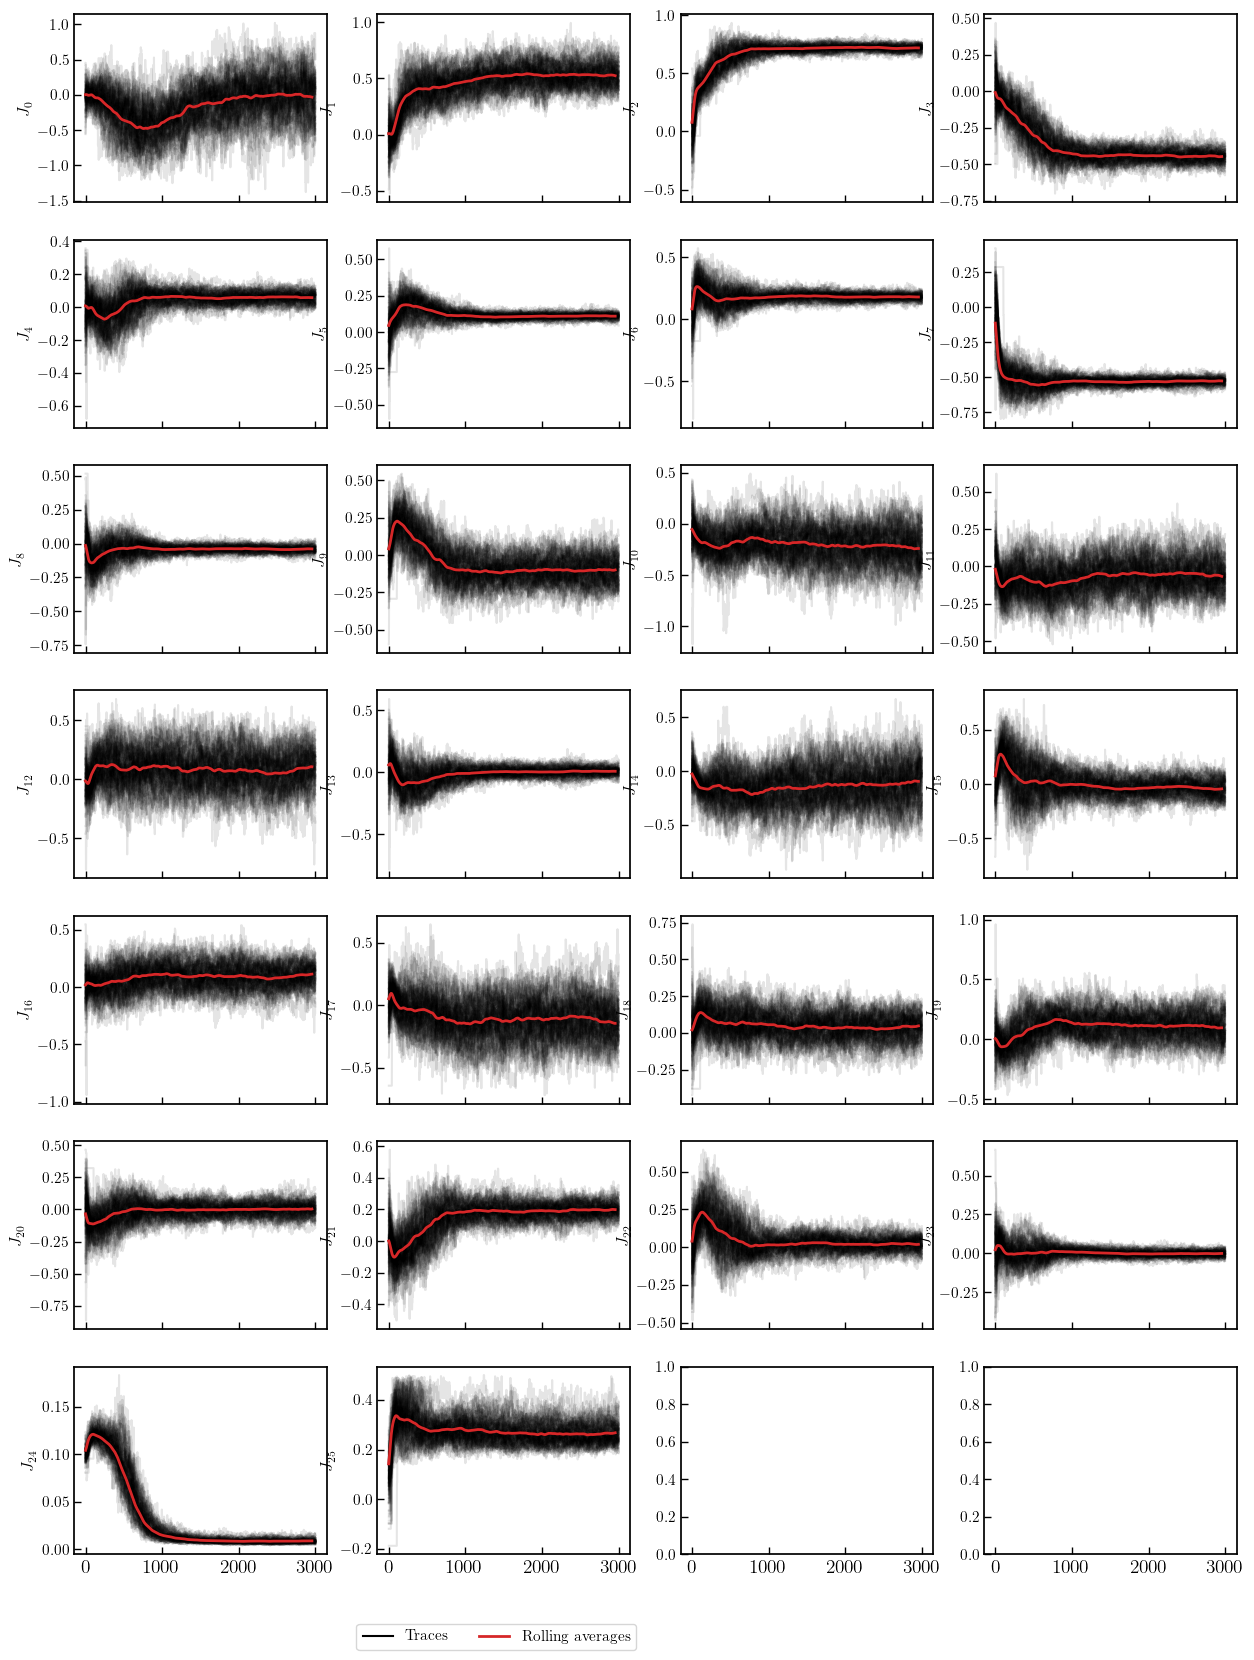

In [191]:

file = 'data/chain_task3.h5'
if os.path.exists(file):
    os.remove(file)

n_walkers = 100
n_steps_burn = 3000
ndim = 2 + len(J_opt_ridge_std)  # J, sigma_sys^2, alpha = 26
p0 = np.zeros((n_walkers, ndim))
p0[:, :len(J_opt_ridge_std)] = np.random.normal(loc=0, scale=0.2, size=(n_walkers, len(J_opt_ridge_std))) # J
p0[:, len(J_opt_ridge_std)] = np.random.normal(loc=0.1, scale=0.01, size=n_walkers) # sigma_sys^2
p0[:, len(J_opt_ridge_std) + 1] = np.random.normal(loc=0.1, scale=0.1, size=n_walkers) # alpha

sampler = emcee.EnsembleSampler(n_walkers, ndim, log_posterior, backend=emcee.backends.HDFBackend('data/chain_task3.h5'), args=(X_std, E_std))
pos, prob, state = sampler.run_mcmc(p0, n_steps_burn, progress=True)

fig, axs = plt.subplots(nrows=7, ncols=4, figsize=(15, 20), sharex=True)
trace_plotter(axs.flatten()[:-2], sampler, iterations=n_steps_burn, sampler_idx='_task3', ndim=ndim, save=False)


In [193]:

sampler.reset()
final_pos, final_prob, final_state = sampler.run_mcmc(pos, 1000, progress=True)


100%|██████████| 1000/1000 [00:58<00:00, 17.10it/s]


In [ ]:

# fig, axs = plt.subplots(nrows=7, ncols=4, figsize=(15, 20), sharex=True)
# trace_plotter(axs.flatten()[:-2], sampler, iterations=500, sampler_idx='_task3', ndim=ndim, save=False)

# plt.tight_layout()
# plt.show()

res = {
    'Parameter': [],
    'Mean': [],
    'Std': [],
    '3 stds Includes 0?': [],
}
samples = sampler.get_chain(flat=True)
params_names = [f'J_{i}' for i in range(len(J_opt_ridge_std))] + ['sigma_sys^2', 'alpha']
for i, name in enumerate(params_names):
    param_samples = samples[:, i]
    mean = np.mean(param_samples)
    std = np.std(param_samples)
    includes_zero = (mean - 3 * std <= 0) and (mean + 3 * std >= 0)
    res['Parameter'].append(name)
    res['Mean'].append(mean)
    res['Std'].append(std)
    res['3 stds Includes 0?'].append(includes_zero)
df_results = pd.DataFrame(res)
print(df_results)

J_samples = samples[:, :-2]
J_sample = J_samples[19, :]
J_sample_recovered = J_sample / scaler_X.scale_ * scaler_E.scale_


      Parameter      Mean       Std  3 stds Includes 0?
0           J_0 -0.000260  0.271459                True
1           J_1  0.520158  0.098685               False
2           J_2  0.717211  0.026569               False
3           J_3 -0.442914  0.043910               False
4           J_4  0.056717  0.035502                True
5           J_5  0.109440  0.018616               False
6           J_6  0.180200  0.030340               False
7           J_7 -0.529790  0.024986               False
8           J_8 -0.039720  0.022937                True
9           J_9 -0.103441  0.087482                True
10         J_10 -0.219878  0.170179                True
11         J_11 -0.059862  0.104091                True
12         J_12  0.089495  0.149156                True
13         J_13  0.009776  0.033155                True
14         J_14 -0.121492  0.177492                True
15         J_15 -0.037582  0.075172                True
16         J_16  0.109193  0.101586             

## **Task 5: ARDR Feature selection**

In [204]:

prim_ardr = db.get(formula='AuCu').toatoms()
cs_ardr = icet.ClusterSpace(prim_ardr, cutoffs=[13, 8, 6], chemical_symbols=['Au', 'Cu'])

sc_ardr = icet.StructureContainer(cs_ardr)
for row in db.select():
    sc_ardr.add_structure(row.toatoms(), properties=dict(mixing_energy=row.mixing_energy))
X_ardr, E_ardr = sc_ardr.get_fit_data(key='mixing_energy')

# Standardize features
scaler_X_ardr = StandardScaler()
X_ardr = scaler_X_ardr.fit_transform(X_ardr)
scaler_E_ardr = StandardScaler()
E_ardr = scaler_E_ardr.fit_transform(E_ardr.reshape(-1, 1)).flatten()

lambda_thresholds = np.logspace(-2, 5, 200)

res_dict = {
    'lambda': [],
    'training_rmse': [],
    'cv_rmse': [],
    'n_nonzero_ecis': [],
    'bic': [],
    'aic': [],
    'J': []
}
for lam in lambda_thresholds:
    ard = ARDRegression(threshold_lambda=lam, fit_intercept=False)
    ard.fit(X_ardr, E_ardr)
    training_error = np.sqrt(np.mean((E_ardr - ard.predict(X_ardr))**2))
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    cv_error = np.sqrt(-cross_val_score(ard, X_ardr, E_ardr, cv=kf, scoring='neg_mean_squared_error').mean())
    cv_error_recovered = scaler_E_ardr.scale_[0] * cv_error
    training_error_recovered = scaler_E_ardr.scale_[0] * training_error
    n_nonzero = np.sum(ard.coef_ != 0)
    aic = - 2 * n_nonzero - len(E_ardr) * np.log(training_error**2)
    bic = - n_nonzero * np.log(len(E_ardr)) - len(E_ardr) * np.log(training_error**2)
    res_dict['lambda'].append(lam)
    res_dict['training_rmse'].append(training_error_recovered * 1000)
    res_dict['cv_rmse'].append(cv_error_recovered * 1000)
    res_dict['n_nonzero_ecis'].append(n_nonzero)
    res_dict['bic'].append(bic)
    res_dict['aic'].append(aic)
    res_dict['J'].append(ard.coef_)

lambda_opt = lambda_thresholds[np.argmin(res_dict['cv_rmse'])]
J_opt_ardr_std = res_dict['J'][np.argmin(res_dict['cv_rmse'])]
J_opt_ardr_recovered = J_opt_ardr_std / scaler_X_ardr.scale_ * scaler_E_ardr.scale_[0]
print(f'Optimal lambda for ARD regression: {lambda_opt}')
    

Optimal lambda for ARD regression: 1162.322468679852


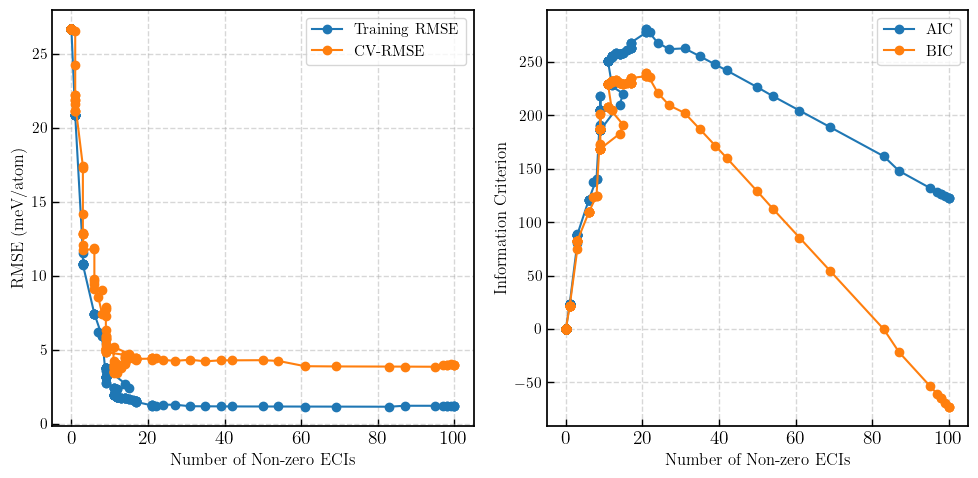

In [ ]:

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
axs[0].plot(res_dict['n_nonzero_ecis'], res_dict['training_rmse'], label='Training RMSE', marker='o')
axs[0].plot(res_dict['n_nonzero_ecis'], res_dict['cv_rmse'], label='CV-RMSE', marker='o')
axs[0].set_xlabel('Number of Non-zero ECIs')
axs[0].set_ylabel('RMSE (meV/atom)')
axs[0].legend()
axs[0].grid(True, linestyle='--', alpha=0.5)

axs[1].plot(res_dict['n_nonzero_ecis'], res_dict['aic'], label='AIC', marker='o')
axs[1].plot(res_dict['n_nonzero_ecis'], res_dict['bic'], label='BIC', marker='o')
axs[1].set_xlabel('Number of Non-zero ECIs')
axs[1].set_ylabel('Information Criterion')
axs[1].legend()
axs[1].grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
# plt.savefig('figs/ardr_ic_vs_n_nonzero_ecis.pdf', bbox_inches='tight')
plt.show()

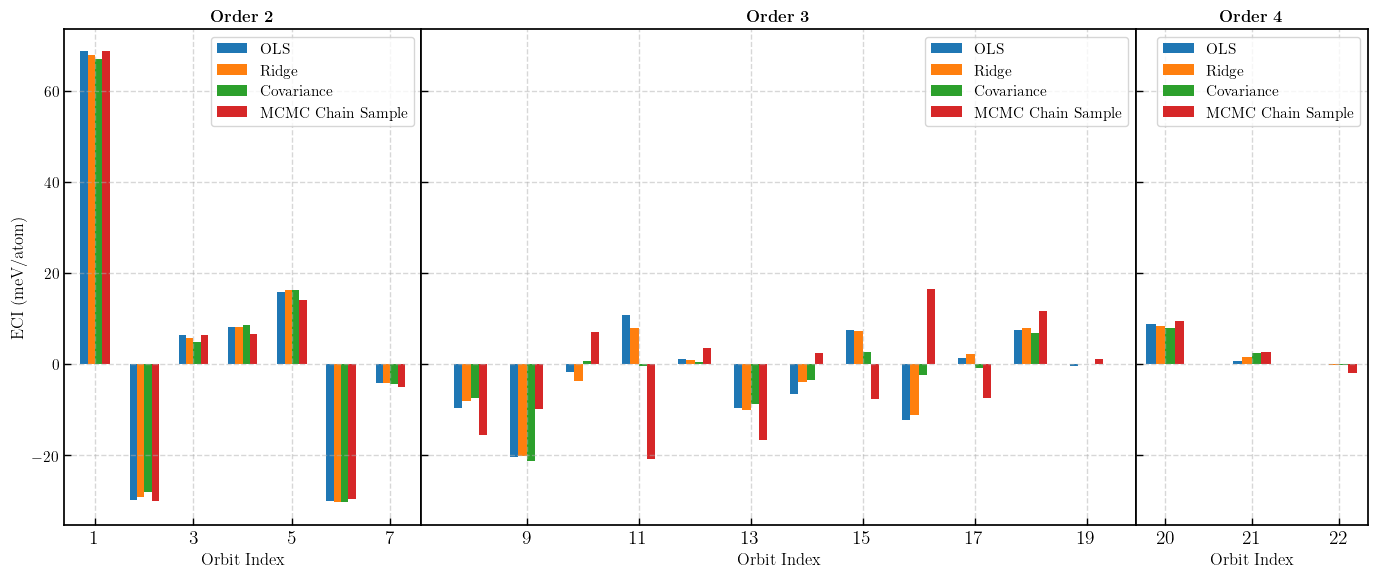

In [ ]:

fig, axes = plt.subplots(ncols=3, sharey=True, figsize=(14, 6), gridspec_kw={'width_ratios': [1, 2, 0.65]})
df_cs = cs.to_dataframe()
cluster_orders = df_cs['order'].values
cluster_indices = df_cs['orbit_index'].values
width = 0.6
bar_width = width / 4

for order, ax in enumerate(axes, start=2):
    index = cluster_orders == order
    if order == 2:
        ax.set_ylabel('ECI (meV/atom)')
        ax.set_xticks([1, 3, 5, 7])
    elif order == 3:
        ax.set_xticks([9, 11, 13, 15, 17, 19])
    else:
        ax.set_xticks([20, 21, 22])
        bar_width = width / 5.5
    ax.bar(cluster_indices[index] - bar_width * 1.5, 1000 * J_opt_OLS_recovered[index], width=bar_width, label='OLS', color='tab:blue', alpha=1)
    ax.bar(cluster_indices[index] - bar_width * 0.5, 1000 * J_opt_ridge_recovered[index], width=bar_width, label='Ridge', color='tab:orange', alpha=1)
    ax.bar(cluster_indices[index] + bar_width * 0.5, 1000 * J_opt_cov_recovered[index], width=bar_width, label='Covariance', color='tab:green', alpha=1)
    ax.bar(cluster_indices[index] + bar_width * 1.5, 1000 * J_sample_recovered[index], width=bar_width, label='MCMC Chain Sample', color='tab:red', alpha=1)
    ax.set_xlabel('Orbit Index')
    ax.set_title(f'\\textbf{{Order {order}}}')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
fig.subplots_adjust(wspace=0, hspace=0)
fig.align_ylabels(axes)
# plt.savefig('figs/eci_comparison_ols_ridge_cov_mcmc.pdf', bbox_inches='tight')


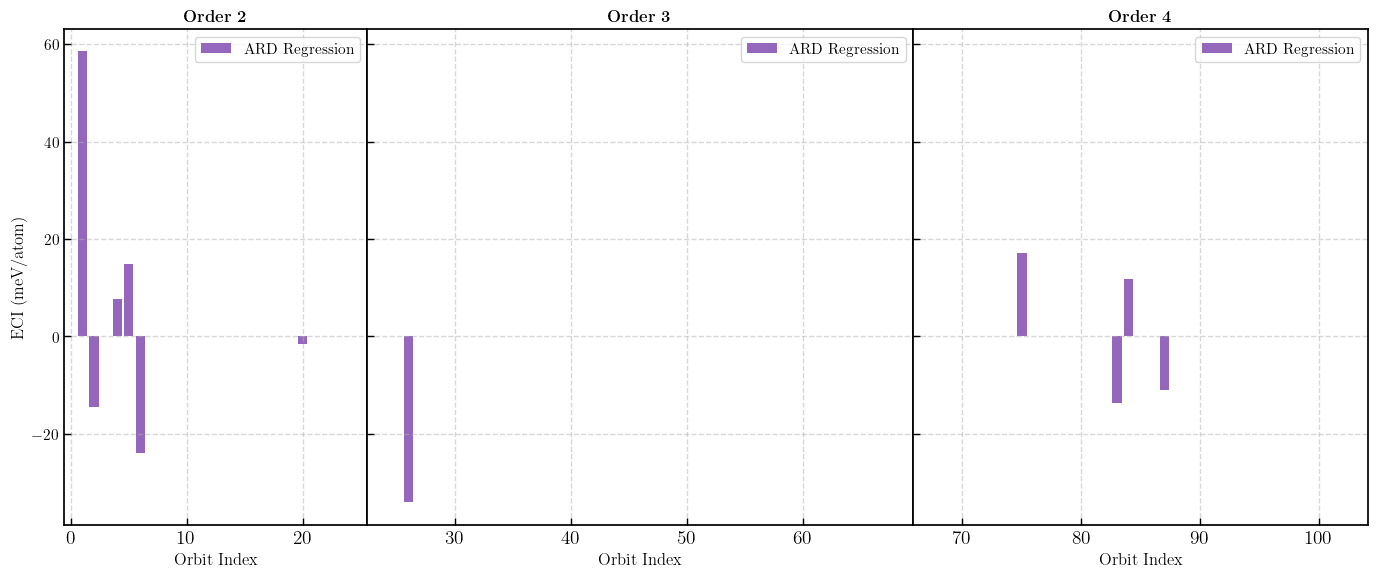

In [226]:

fig, axes = plt.subplots(ncols=3, sharey=True, figsize=(14, 6), gridspec_kw={'width_ratios': [1, 1.8, 1.5]})
df_cs_ardr = cs_ardr.to_dataframe()
cluster_orders = df_cs_ardr['order'].values
cluster_indices = df_cs_ardr['orbit_index'].values
width = 0.8

for order, ax in enumerate(axes, start=2):
    index = cluster_orders == order
    ax.bar(cluster_indices[index], 1000 * J_opt_ardr_recovered[index], width=width, label='ARD Regression', color='tab:purple', alpha=1)
    ax.set_xlabel('Orbit Index')
    ax.set_title(f'\\textbf{{Order {order}}}')
    if order == 2:
        ax.set_ylabel('ECI (meV/atom)')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
fig.subplots_adjust(wspace=0, hspace=0)
fig.align_ylabels(axes)

## **Task 6: The ground state**

In [218]:

db_gs = ase.db.connect('data/ground-state-candidates.db')

candidate_structs = []
candidate_ids = []
X_gs_raw = []
X_gs_ardr_raw = []
cu_concentrations_gs = []

for row in db_gs.select():
    atoms = row.toatoms()
    candidate_structs.append(atoms)
    candidate_ids.append(row.id)
    X_gs_raw.append(cs.get_cluster_vector(atoms))
    X_gs_ardr_raw.append(cs_ardr.get_cluster_vector(atoms))
    cu_concentrations_gs.append(find_cu_concentration(atoms.get_chemical_formula()))

X_gs_raw = np.array(X_gs_raw)
X_gs = scaler_X.transform(X_gs_raw)

X_gs_ardr_raw = np.array(X_gs_ardr_raw)
X_gs_ardr = scaler_X_ardr.transform(X_gs_ardr_raw)


In [219]:

ids = []
gs_energies = []
for sample in J_samples:
    E_pred_bayes = X_gs @ sample
    E_pred_bayes = scaler_E.inverse_transform(E_pred_bayes.reshape(-1, 1)).flatten()
    ids.append(candidate_ids[np.argmin(E_pred_bayes)])
    gs_energies.append(np.min(E_pred_bayes))


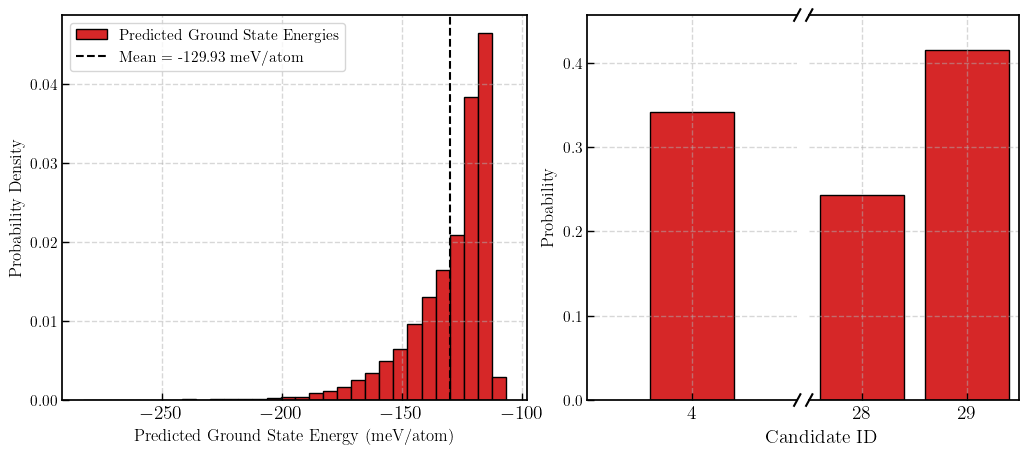

In [ ]:

fig, ax = plt.subplots(figsize=(6, 5))
plt.hist(1000 * np.array(gs_energies), bins=30, color='tab:red', alpha=1, edgecolor='black', density=True, label='Predicted Ground State Energies')
plt.axvline(x=np.mean(1000 * np.array(gs_energies)), color='k', linestyle='--', label=f'Mean = {np.mean(1000 * np.array(gs_energies)):.2f} meV/atom')
plt.xlabel('Predicted Ground State Energy (meV/atom)')
plt.ylabel('Probability Density')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
ids_unique, counts = np.unique(ids, return_counts=True)
probs = counts / np.sum(counts)

# Split data for the broken axis
left_mask  = ids_unique <= 5
right_mask = ids_unique >= 27

ids_left   = ids_unique[left_mask]
probs_left = probs[left_mask]

ids_right   = ids_unique[right_mask]
probs_right = probs[right_mask]

# --- Create subplots with shared y-axis ---
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5), sharey=True)
# plt.subplots_adjust(wspace=0.05)
ax1 = fig.add_axes([1, 0.11, 0.35, 0.77])
ax2 = fig.add_axes([1.37, 0.11, 0.35, 0.77])
ax1.grid(True, linestyle='--', alpha=0.5)
ax2.grid(True, linestyle='--', alpha=0.5)

# --- Plot bars ---
ax1.bar(ids_left, probs_left, color='tab:red', alpha=1, edgecolor='black', width=0.08)
ax2.bar(ids_right, probs_right, color='tab:red', alpha=1, edgecolor='black')

# --- Set x-limits ---
ax1.set_xlim(ids_left.min() - 0.1, ids_left.max() + 0.1)
ax2.set_xlim(ids_right.min() - 0.5, ids_right.max() + 0.5)

# --- Manually synchronize y-limits ---
ymin = 0
ymax = max(max(probs_left), max(probs_right)) * 1.1
ax1.set_ylim(ymin, ymax)
ax2.set_ylim(ymin, ymax)

# --- Hide spines between subplots ---
ax1.spines.right.set_visible(False)
ax2.spines.left.set_visible(False)
ax1.tick_params(right=False)
ax2.tick_params(left=False)
ax1.set_xticks([4])
ax2.set_yticklabels([])

# --- Diagonal break marks ---
d = 0.015
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((1-d,1+d), (-d,d), **kwargs)
ax1.plot((1-d,1+d), (1-d,1+d), **kwargs)
kwargs = dict(transform=ax2.transAxes, color='k', clip_on=False)
ax2.plot((-d,d), (-d,d), **kwargs)
ax2.plot((-d,d), (1-d,1+d), **kwargs)

# --- Labels ---
ax1.set_ylabel("Probability")
ax1.text(4.07, -0.05, "Candidate ID")

# plt.savefig('figs/gs_candidate_probabilities.pdf', bbox_inches='tight')
plt.show()


Lowest energy and corresponding structure ids for each model:
OLS: ID 4 with Energy -0.1170 eV/atom
Ridge: ID 4 with Energy -0.1166 eV/atom
Covariance: ID 29 with Energy -0.1210 eV/atom
ARD Regression: ID 4 with Energy -0.1182 eV/atom


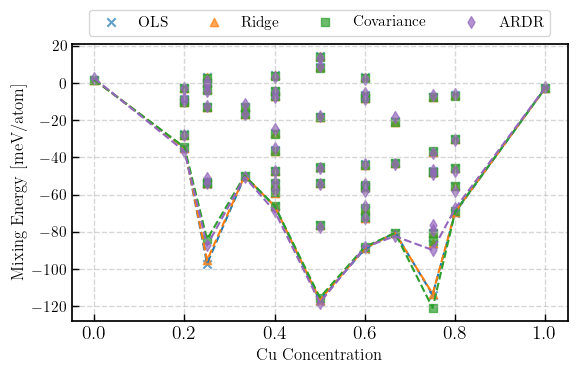

In [ ]:

E_pred_OLS = X_gs_raw @ J_opt_OLS_recovered + intercept_OLS
E_pred_ridge = X_gs_raw @ J_opt_ridge_recovered + intercept_ridge

J_opt_cov_recovered = J_opt_cov_std / scaler_X.scale_ * scaler_E.scale_
intercept_cov = scaler_E.mean_ - scaler_X.mean_ @ J_opt_cov_recovered
E_pred_cov = X_gs_raw @ J_opt_cov_recovered + intercept_cov
J_opt_ardr_recovered = J_opt_ardr_std / scaler_X_ardr.scale_ * scaler_E_ardr.scale_
intercept_ardr = scaler_E_ardr.mean_ - scaler_X_ardr.mean_ @ J_opt_ardr_recovered
E_pred_ardr = X_gs_ardr_raw @ J_opt_ardr_recovered + intercept_ardr

print('Lowest energy and corresponding structure ids for each model:')
print(f'OLS: ID {candidate_ids[np.argmin(E_pred_OLS)]} with Energy {np.min(E_pred_OLS):.4f} eV/atom')
print(f'Ridge: ID {candidate_ids[np.argmin(E_pred_ridge)]} with Energy {np.min(E_pred_ridge):.4f} eV/atom')
print(f'Covariance: ID {candidate_ids[np.argmin(E_pred_cov)]} with Energy {np.min(E_pred_cov):.4f} eV/atom')
print(f'ARD Regression: ID {candidate_ids[np.argmin(E_pred_ardr)]} with Energy {np.min(E_pred_ardr):.4f} eV/atom')

def get_lowest_concentration_Es(cu_concentrations, E_preds):
    unique_concentrations = sorted(set(cu_concentrations))
    lowest_Es = []
    for conc in unique_concentrations:
        lowest_E = np.min([E for c, E in zip(cu_concentrations, E_preds) if c == conc])
        lowest_Es.append(lowest_E)
    return np.array(lowest_Es), unique_concentrations

ols_sorted_E_preds, ols_unique_concentrations = get_lowest_concentration_Es(cu_concentrations_gs, E_pred_OLS)
ridge_sorted_E_preds, ridge_unique_concentrations = get_lowest_concentration_Es(cu_concentrations_gs, E_pred_ridge)
cov_sorted_E_preds, cov_unique_concentrations = get_lowest_concentration_Es(cu_concentrations_gs, E_pred_cov)
ardr_sorted_E_preds, ardr_unique_concentrations = get_lowest_concentration_Es(cu_concentrations_gs, E_pred_ardr)

plt.figure(figsize=(6, 4))
plt.scatter(cu_concentrations_gs, E_pred_OLS * 1000, label='OLS', color='tab:blue', alpha=0.7, marker='x')
plt.plot(ols_unique_concentrations, ols_sorted_E_preds * 1000, color='tab:blue', linestyle='--')
plt.scatter(cu_concentrations_gs, E_pred_ridge * 1000, label='Ridge', color='tab:orange', alpha=0.7, marker='^')
plt.plot(ridge_unique_concentrations, ridge_sorted_E_preds * 1000, color='tab:orange', linestyle='--')
plt.scatter(cu_concentrations_gs, E_pred_cov * 1000, label='Covariance', color='tab:green', alpha=0.7, marker='s')
plt.plot(cov_unique_concentrations, cov_sorted_E_preds * 1000, color='tab:green', linestyle='--')
plt.scatter(cu_concentrations_gs, E_pred_ardr * 1000, label='ARDR', color='tab:purple', alpha=0.7, marker='d')
plt.plot(ardr_unique_concentrations, ardr_sorted_E_preds * 1000, color='tab:purple', linestyle='--')
plt.xlabel('Cu Concentration')
plt.ylabel('Mixing Energy [meV/atom]')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=4)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
# plt.savefig('figs/au_cu_gs_candidate_energies.pdf', bbox_inches='tight')
plt.show()
